## Experiment 07: Comparison of Different Regression Algorithms

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of samples: 20640
Number of features: 8


Display Feature Names

In [3]:
print("Feature Names:")
print(data.feature_names)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Convert Dataset into DataFrame

In [4]:
df = pd.DataFrame(X, columns=data.feature_names)
df["MedHouseVal"] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Check Dataset Information

In [5]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (20640, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Check Missing Values

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Data Visualization

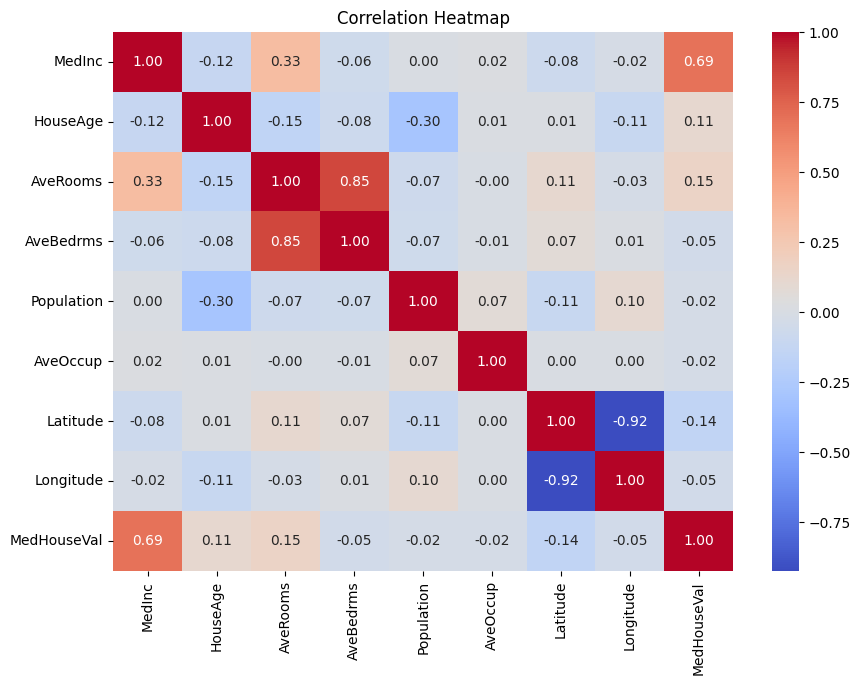

In [8]:
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Target Distribution

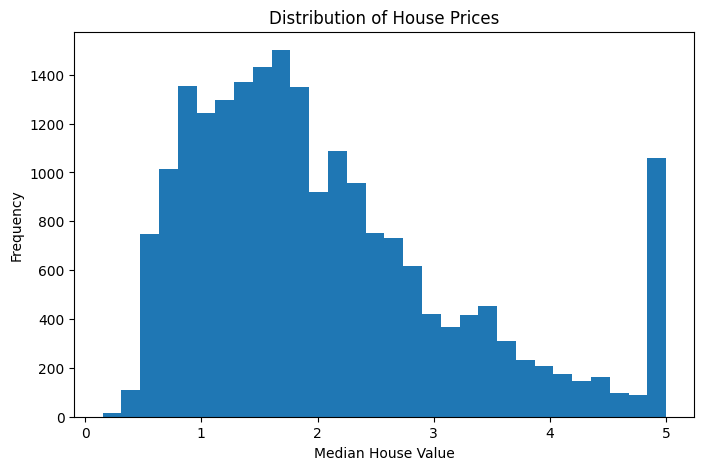

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


## Model 1 — Linear Regression

In [11]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

Evaluate Linear Regression

In [12]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("------------------------")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R2  :", r2_linear)

Linear Regression
------------------------
MAE : 0.5332001304956983
MSE : 0.555891598695242
RMSE: 0.7455813830127748
R2  : 0.5757877060324526


## Model 2 — Polynomial Regression

In [13]:
poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Polynomial features:", X_poly_train.shape[1])

Original number of features: 8
Polynomial features: 45


In [14]:
poly_model = LinearRegression()

poly_model.fit(X_poly_train, y_train)

y_pred_poly = poly_model.predict(X_poly_test)

In [15]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("------------------------")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R2  :", r2_poly)

Polynomial Regression
------------------------
MAE : 0.4670009334817138
MSE : 0.4643015265756107
RMSE: 0.6813967468190691
R2  : 0.6456819708310517


## Model 3 — Decision Tree Regression

In [16]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [17]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression")
print("------------------------")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R2  :", r2_tree)

Decision Tree Regression
------------------------
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R2  : 0.622075845135081


## Model 4 — Random Forest Regression

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [19]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Regression
------------------------
MAE : 0.3275425684593025
MSE : 0.2553684927247781
RMSE: 0.5053399773665033
R2  : 0.8051230593157366


## Model 5 — Support Vector Regression

In [23]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(
    y_train.reshape(-1, 1)
).ravel()

In [24]:
svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(
    X_train_scaled,
    y_train_scaled
)

y_pred_svr_scaled = svr_model.predict(X_test_scaled)

Convert Predictions Back to Original Scale

In [25]:
y_pred_svr = scaler_y.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

## Evaluate SVR

In [26]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regression")
print("------------------------")
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R2  :", r2_svr)

Support Vector Regression
------------------------
MAE : 0.3972829303041437
MSE : 0.3541509600381317
RMSE: 0.5951058393581193
R2  : 0.7297401300519584


## Final Comparison

In [27]:
## Create Comparison Table
results = {
    "Linear Regression": [
        mae_linear,
        mse_linear,
        rmse_linear,
        r2_linear
    ],

    "Polynomial Regression": [
        mae_poly,
        mse_poly,
        rmse_poly,
        r2_poly
    ],

    "Decision Tree": [
        mae_tree,
        mse_tree,
        rmse_tree,
        r2_tree
    ],

    "Random Forest": [
        mae_rf,
        mse_rf,
        rmse_rf,
        r2_rf
    ],

    "SVR": [
        mae_svr,
        mse_svr,
        rmse_svr,
        r2_svr
    ]
}

results_df = pd.DataFrame(
    results,
    index=["MAE", "MSE", "RMSE", "R2 Score"]
).T

results_df

,MAE,MSE,RMSE,R2 Score
Linear Regression,0.533200,0.555892,0.745581,0.575788
Polynomial Regression,0.467001,0.464302,0.681397,0.645682
Decision Tree,0.454679,0.495235,0.703729,0.622076
Random Forest,0.327543,0.255368,0.505340,0.805123
SVR,0.397283,0.354151,0.595106,0.729740


## Visualization of Results

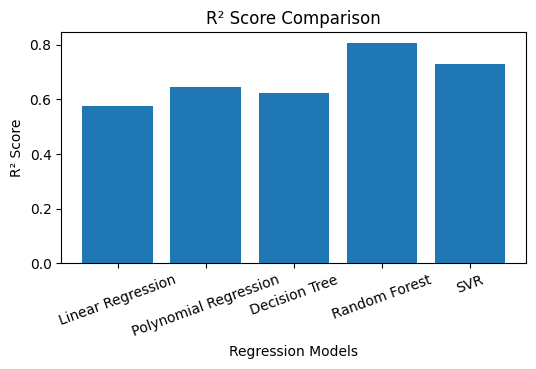

In [34]:
##Compare R² Scores
plt.figure(figsize=(6, 3))

plt.bar(
    results_df.index,
    results_df["R2 Score"]
)

plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.xticks(rotation=20)

plt.show()

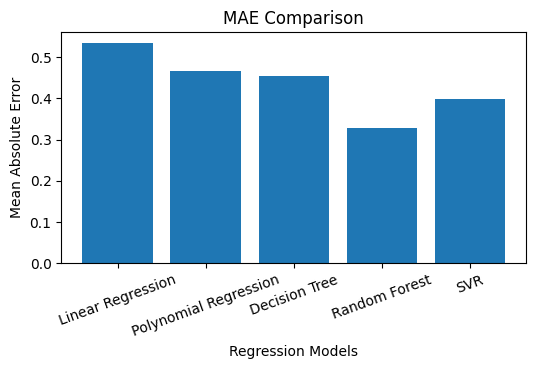

In [33]:
## Compare MAE
plt.figure(figsize=(6, 3))

plt.bar(
    results_df.index,
    results_df["MAE"]
)

plt.xlabel("Regression Models")
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison")

plt.xticks(rotation=20)

plt.show()

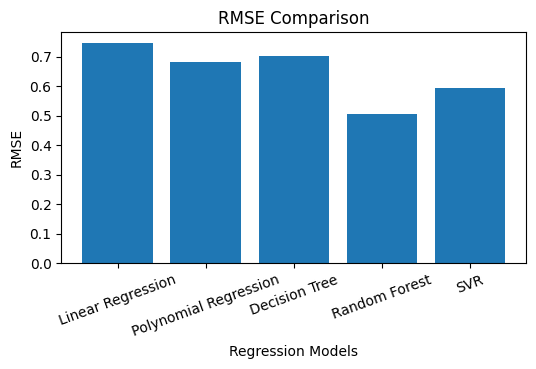

In [35]:
## Compare RMSE
plt.figure(figsize=(6, 3))

plt.bar(
    results_df.index,
    results_df["RMSE"]
)

plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=20)

plt.show()

## Actual vs Predicted Values

Random Forest Actual vs Predicted

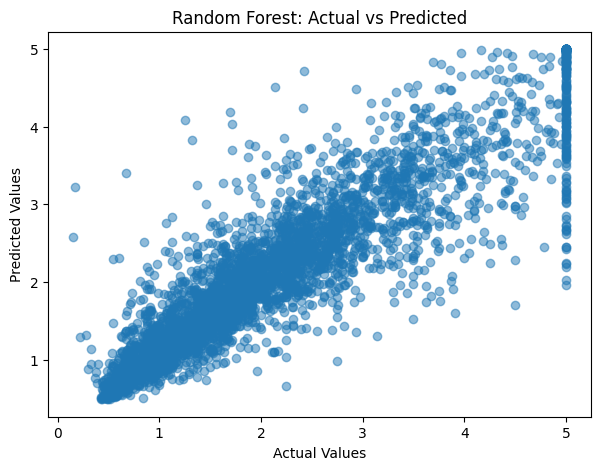

In [36]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

## Feature Importance

In [37]:
## Random Forest Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=data.feature_names
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print(feature_importance)

MedInc        0.524871
AveOccup      0.138443
Latitude      0.088936
Longitude     0.088629
HouseAge      0.054593
AveRooms      0.044272
Population    0.030650
AveBedrms     0.029606
dtype: float64


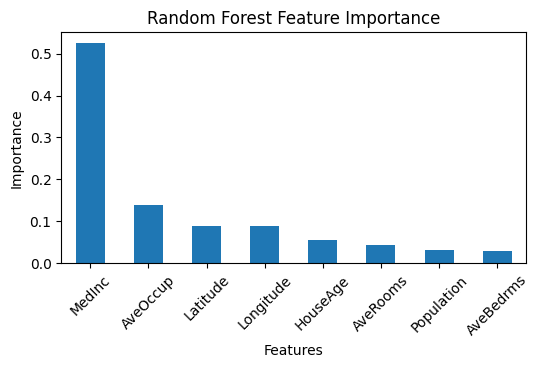

In [39]:
## Feature Importance Graph
plt.figure(figsize=(6,3))

feature_importance.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

## Automatically Find the Best Model

In [40]:
## Best Model Based on R²
best_model = results_df["R2 Score"].idxmax()

print("Model with highest R² Score:")
print(best_model)

Model with highest R² Score:
Random Forest


## Conclusion

The five regression algorithms were compared using MAE, MSE, RMSE, and R² Score. Among the tested models, **Random Forest Regression performed best**, giving higher prediction accuracy and lower errors. Therefore, Random Forest is the most suitable model for the given California Housing dataset.
